In [11]:
import h5py
import helpers
import numpy as np
from pathlib import Path
import torch
from torch.utils import data
from torch.utils.data.dataloader import default_collate

import gc
from accelerate import Accelerator

import os.path as osp
import os

import cloudpickle as pickle
import sys,os,json

from dataloader import *
from nets import *

# --------------------------------------------------------------------------------------

def save_obj(obj, name):
    with open(name + '.pkl', 'wb') as f:
        pickle.dump(obj, f)
        
def load_obj(name):
    with open(name, 'rb') as f:
        return pickle.load(f)
    

# --------------------------------------------------------------------------------------
# custom log-mse loss

class logMSELoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.mse = nn.MSELoss()
        
    def forward(self, pred, actual):
        return torch.log(self.mse(pred, actual))

# --------------------------------------------------------------------------------------



### READ IN CONFIGS
config_file_path = 'configs_30_09.json'


with open(config_file_path) as f:
        configs = json.load(f)



# model stuff
# HIDDEN_CHANNELS = configs["model_params"][model_type][model_size]["hidden_channels"]
# NUM_LAYERS = configs["model_params"][model_type][model_size]["num_layers"]
# MODEL_NAME = configs["model_params"][model_type][model_size]["name"]
# TEST_BATCHING = configs["model_params"][model_type][model_size]["test_batching"]
        
FILTERS = configs["model_params"]["filters"]
NOISEAMP = configs["model_params"]["noiseamp"]
N_FG = configs["model_params"]["n_fg"]
MODEL_PATH = configs["model_params"]["model_path"]
MODEL_NAME = configs["model_params"]["model_name"]
ADD_NOISE = True



# # optimizer schedule
LEARNING_RATE = configs["training_params"]["learning_rate"]
BATCH_SIZE = configs["training_params"]["batch_size"]
EPOCHS = int(configs["training_params"]["epochs"])
#DO_SCHEDULER = bool(int(configs["training_params"]["do_lr_scheduler"]))
SEED = int(configs["training_params"]["seed"])

# # data + out directories
cosmopath = configs["training_params"]["cosmopath"]
galpath = configs["training_params"]["galpath"]


MODEL_DIR = configs["model_params"]["model_dir"]
LOAD_DIR = configs["model_params"]["load_dir"]


if not os.path.exists(MODEL_DIR):
   # Create a new directory if it does not exist
   os.makedirs(MODEL_DIR)
   print("created new directory", MODEL_DIR)

# ### CONSTRUCT MODEL NAME AND OUTPUT PATH
# MODEL_NAME += "nc_%d_nlyr_%d"%(HIDDEN_CHANNELS, NUM_LAYERS)
# MODEL_PATH = MODEL_DIR + MODEL_NAME
# LOAD_PATH = LOAD_DIR + MODEL_NAME



# --------------------------------------------------------------------------------------
    
print("LOADING DATA AND INITIALISING DATALOADERS")

# fix random seed
np.random.seed(SEED)
torch.manual_seed(SEED)

# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

cosmofiles = os.listdir(cosmopath)
galfiles = os.listdir(galpath)

# save the filenames 
#save_obj(cosmofiles, "/data101/makinen/hirax_sims/dataloader/cosmofiles")
#save_obj(galfiles, "/data101/makinen/hirax_sims/dataloader/galfile")



cosmofiles = [cosmopath + p for p in cosmofiles]
galfiles =  [galpath + p for p in galfiles]


# random mask for train/val split
mask = np.random.rand(len(cosmofiles)) < 0.9
train_cosmo_files = list(np.array(cosmofiles)[mask])
val_cosmo_files = list(np.array(cosmofiles)[~mask])

galmask = np.random.rand(len(galfiles)) < 0.9
train_gal_files = list(np.array(galfiles)[galmask])
val_gal_files = list(np.array(galfiles)[~galmask])



# get test set
testpath = '/data101/makinen/hirax_sims/cosmo_test_set/'
cosmo_test_files = os.listdir(testpath)
cosmo_test_files = [testpath + p for p in cosmo_test_files]



# save the train/val masks
#np.save("/data101/makinen/hirax_sims/dataloader/cosmo_mask", mask)
#np.save("/data101/makinen/hirax_sims/dataloader/gal_mask", galmask)


# --------------------------------------------------------------------------------------


def preprocess_data(x,y):
    
        # split ordering (batch, baseline, freq, ra) = (batch*split, 48, 128, 128)
        # then transpose to (batch*split, freq, ra, baseline)
        x = torch.permute(
            torch.cat(torch.tensor_split(x, split, dim=3)),
            (0, 3, 1, 2)
        )
        y = torch.permute(
                torch.cat(torch.tensor_split(y, split, dim=3)),
                (0, 3, 1, 2)
        )
        # then finally get the real and im parts as channels
        # shape: (batch*split, freq, ra, baseline, Re/Im)
        x = torch.stack([x.real, x.imag], dim=-1)
        y = torch.stack([y.real, y.imag], dim=-1)
        
        
        # add white noise to the signal
        if ADD_NOISE:
            x += torch.normal(mean=0.0, std=torch.ones(x.shape)*NOISEAMP) #.to(device)
        
        # pass x to the pca
        x = PCALayer(x, N_FG=N_FG)
        
        # get y into same shape as model outputs
        y = torch.permute(y, (0, 4, 2, 1, 3))
        
        return x.to(device),y.to(device)
    

def my_collate_fn(batch):
    x,y = batch
    x,y = preprocess_data(x,y)
    return x.to(device), y.to(device)


# --------------------------------------------------------------------------------------


# create train and val datasets and loaders with collate fn

print("INITIALISING dataloaders")
# train_dataset = H5Dataset(train_cosmo_files, train_gal_files, use_cache=False)
val_dataset = H5Dataset(cosmo_test_files, val_gal_files, use_cache=False)


# train_dataloader = DataLoader(
#     train_dataset,
#     batch_size=2,  # bigger batch ?
#     num_workers=10, # how high can we go ?
#     shuffle=False,
#     pin_memory=True, # do we need this ?
#     collate_fn=my_collate_fn
# )

val_dataloader = DataLoader(
    val_dataset,
    num_workers=0,
    shuffle=False,
    pin_memory=True
)


LOADING DATA AND INITIALISING DATALOADERS
INITIALISING dataloaders


In [12]:
cosmopath

'/data101/makinen/hirax_sims/cosmo_gaussian_pb/'

In [13]:
pwd

'/home/makinen/repositories/hugh/torch_unet'

In [14]:
FILTERS

16

In [15]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [16]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


split = 1024 // 128 # 8 chunks per sky simulation


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = UNet3d(BasicBlock, filters=FILTERS).to(device)
#model = UNet3DWithAttention(in_channels=2, out_channels=2, init_features=FILTERS)

# # start up the optimizer
# optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = logMSELoss()

model_path = MODEL_PATH
model_path += MODEL_NAME
# accelerator = Accelerator(project_dir=model_path)

# model, optimizer, train_dataloader = accelerator.prepare(
#                 model, optimizer, train_dataloader)

In [17]:
model_path

'/data101/makinen/hirax_sims/accelerator/default_30_09'

In [18]:
model.load_state_dict(torch.load(model_path + "/pytorch_model.bin"))
criterion = logMSELoss()

In [16]:
model

UNet3d(
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv3d(2, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), padding_mode=circular)
      (bn1): BatchNorm3d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (1): BasicBlock(
      (conv1): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), padding_mode=circular)
      (bn1): BatchNorm3d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
  )
  (layer2): Sequential(
    (0): BasicBlock(
      (conv1): Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1), padding_mode=circular)
      (bn1): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
  )
  (layer3): Sequential(
    (0): BasicBlock(
      (conv1): Conv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), padding

In [10]:
#from accelerate import init_empty_weights
#with init_empty_weights():
#    model = UNet3d(BasicBlock, filters=16).to(device)


In [19]:
split = 1024 // 128 # 8 chunks per sky simulation


In [20]:
@torch.no_grad()
def test(plot=False, num_preds=5):
    model.eval()

    total_loss = total_examples = 0

    #pbar = tqdm(total=len(val_dataloader), position=0)

    for i,data in tqdm(enumerate(val_dataloader)):
        #if i % 2 == 0:
        x,y = data
        x,y = preprocess_data(x.cpu(),y.cpu())
        
        y *= model.scaling # 
        x *= model.scaling
        
        # model learns residual model(x) = x + y => y_pred = model(x) - x
        preds = model(x) #- x.cpu()
        
        preds = model(x)
        loss = criterion(preds, y)

        preds = preds.cpu()
        y = y.cpu()

        total_loss += float(loss) #* int(data.train_mask.sum())
        total_examples += 1 #data.shape #int(data.train_mask.sum())
        
        if plot:
            plt.subplot(131)
            plt.title("truth")
            plt.imshow(y[0, 0, 0, :, :])
            plt.colorbar()

            plt.subplot(132)
            plt.title("network prediction")
            plt.imshow(preds[0, 0, 0, :, :])
            plt.colorbar()
            
            
            plt.subplot(133)
            plt.title("residual")
            plt.imshow(((preds[0, 0, 0, :, :] - y[0, 0, 0, :, :])))
            plt.colorbar()
            
            plt.show()

0it [00:00, ?it/s]

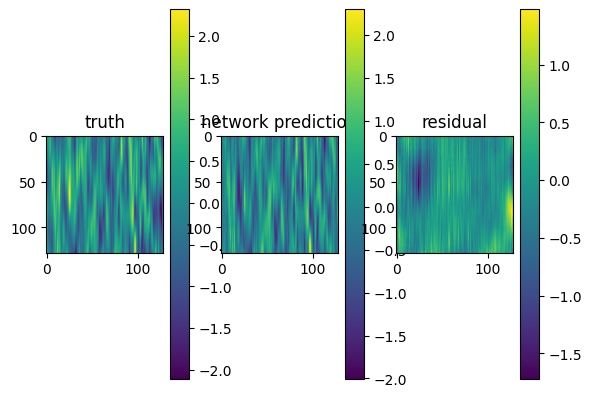

1it [00:16, 16.89s/it]

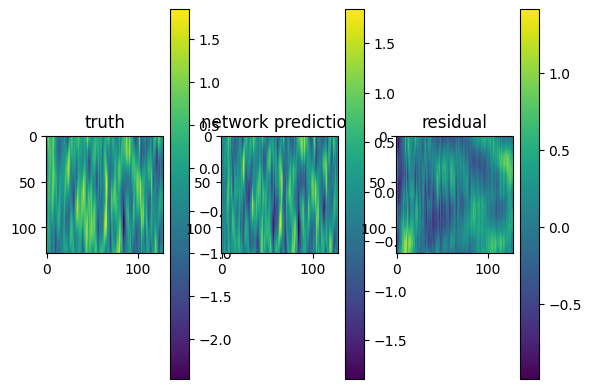

2it [00:21,  9.46s/it]

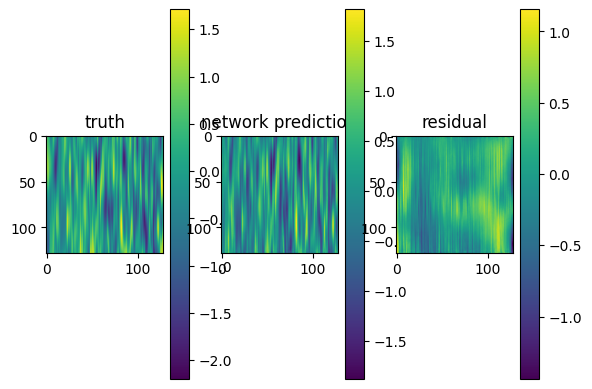

3it [00:25,  8.58s/it]


KeyboardInterrupt: 

In [16]:
test(plot=True)

In [21]:
@torch.no_grad()
def get_one_val_sim():
    
    idx_to_test = 6

    model.eval()
    plot=True

    total_loss = total_examples = 0

    #pbar = tqdm(total=len(val_dataloader), position=0)

    for i,data in tqdm(enumerate(val_dataloader)):
        if i == idx_to_test:
            x,y = data
            x,y = preprocess_data(x.cpu(),y.cpu())

            y *= model.scaling # 
            x *= model.scaling

            # model learns residual model(x) = x + y => y_pred = model(x) - x
            preds = model(x) #- x.cpu()

            preds = model(x)
            loss = criterion(preds, y)

            preds = preds.detach().cpu().numpy()
            y = y.detach().cpu().numpy()

            total_loss += float(loss) #* int(data.train_mask.sum())
            total_examples += 1 #data.shape #int(data.train_mask.sum())

            if plot:
                plt.subplot(131)
                plt.title("truth")
                plt.imshow(y[0, 0, 0, :, :])
                plt.colorbar()

                plt.subplot(132)
                plt.title("network prediction")
                plt.imshow(preds[0, 0, 0, :, :])
                plt.colorbar()


                plt.subplot(133)
                plt.title("residual")
                plt.imshow(((preds[0, 0, 0, :, :] - y[0, 0, 0, :, :])))
                plt.colorbar()

                plt.show()
            
            return x.detach().cpu().numpy(), y, preds

6it [00:13,  2.61s/it]

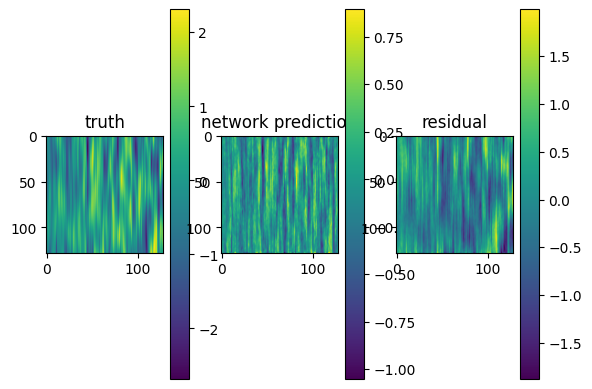

6it [00:16,  2.76s/it]


In [22]:
gc.collect()

x,y,preds = get_one_val_sim()

In [23]:
from astropy.cosmology import FlatLambdaCDM
from astropy import units
from astropy import constants as consts

from scipy.signal.windows import blackmanharris
import matplotlib.pyplot as plt

cosmology = FlatLambdaCDM(H0=100, Om0=0.3) # H0=100 km/s/Mpc so in h units
nu_21 = 1420.405751768*units.MHz

def z21(freq):
    freq = units.Quantity(freq, unit=units.MHz)
    return (nu_21/freq - 1).value

def k_perpendicular(bl_length, freq):
    freq = units.Quantity(freq, unit=units.MHz)
    bl_length = units.Quantity(bl_length, unit=units.m)
    wl = freq.to('m', equivalencies=units.spectral())
    k_pp = 2*np.pi*np.linalg.norm(bl_length)/wl/cosmology.comoving_transverse_distance(z21(freq))
    return k_pp.to('Mpc^-1')

def delays_from_freqs(freqs):
    freqs = units.Quantity(freqs, unit=units.MHz)
    d = (freqs[1]-freqs[0]).to('ns^-1')
    return np.fft.fftshift(np.fft.fftfreq(len(freqs), d=d))

def k_parallel(delays, freq):
    freq = units.Quantity(freq, unit=units.MHz)
    z = z21(freq)
    eta_to_kh = 2*np.pi*nu_21*cosmology.H(z)/consts.c/(1+z)**2
    k_parallel = (eta_to_kh*delays).to('Mpc^-1')
    return k_parallel
    
def wedge(theta_0, bl_ind, band_center=550*units.MHz):
    
    z = z21(band_center)
    wl = band_center.to('m', equivalencies=units.spectral()).value
    
    bl = baselines[bl_ind, ...]*units.m
    
    k_pp = k_perpendicular(np.linalg.norm(bl), band_center)
    k_par = theta_0.to('rad').value*k_pp*((cosmology.H(z)*cosmology.comoving_transverse_distance(z))/(consts.c*(1+z))).to('').value
    
    return k_par*0.7 # Double check h factor

def baseline_delay_spectrum(data, bl_ind, band_center=550*units.MHz):
    
    #with h5py.File(vis_fname, 'r') as fil:
    #    data = fil['vis'][bl_ind, ...] # bl, freq, ras
    
    data = data[bl_ind]
        
    N = data.shape[0] # Number of freqs
    
    z = z21(band_center)
    eta_to_kh = 2*np.pi*nu_21*cosmology.H(z)/consts.c/(1+z)**2
    
    delays = delays_from_freqs(freqs)
    k_par = k_parallel(delays, band_center)
    window = blackmanharris(N)
    
    delay_spec = np.fft.fftshift(np.abs(np.fft.fft(data*window[:, None], axis=0))**2)*units.K**2
    
    return delays, k_par, delay_spec

def plot_delay_spectrum(data, bl_ind, band_center=550*units.MHz, wedge_angle=90*units.deg, rel_range=12):
    
    delays, k_par, delay_spec = baseline_delay_spectrum(data, bl_ind, band_center=band_center)
    
    ras = np.linspace(180, -180, delay_spec.shape[1] + 1)
    
    fig, ax = plt.subplots(figsize=(10, 4))
    
    extent = (ras[0], ras[-1], k_par[0].value, k_par[-1].value)
    
    to_plot = np.log10(delay_spec.value[:, ::-1])
    vmin = to_plot.max() - rel_range
    
    im = ax.imshow(to_plot, vmin=vmin, aspect=100, extent=extent, origin='lower', cmap='magma')
    
    wedge_k_pp = wedge(wedge_angle, bl_ind, band_center=band_center)
    ax.axhline(wedge_k_pp.value, color='white', ls='--')
    ax.axhline(-wedge_k_pp.value, color='white', ls='--')
    
    ax.set_xlabel('RA [deg]')
    ax.set_ylabel(r'$k_{\parallel}$ [h Mpc$^{-1}$]')
    
    plt.colorbar(im, label='[K$^2$]')
    
    return fig

def plot_delay_spectrum_of_residual(data1, data_true, bl_ind, band_center=550*units.MHz, wedge_angle=90*units.deg, rel_range=12):
    
    delays, k_par, delay_spec = baseline_delay_spectrum((data1 - data_true), bl_ind, band_center=band_center)
    
    delays, k_par, delay_spec2 = baseline_delay_spectrum((data_true), bl_ind, band_center=band_center)

    delay_spec /= delay_spec2
    
    
    ras = np.linspace(180, -180, delay_spec.shape[1] + 1)
    
    fig, ax = plt.subplots(figsize=(10, 4))
    
    extent = (ras[0], ras[-1], k_par[0].value, k_par[-1].value)
    
    to_plot = delay_spec.value[:, ::-1] #np.log10(delay_spec.value[:, ::-1])
    vmin = to_plot.max() - rel_range
    
    im = ax.imshow(to_plot, aspect=100, vmin=-2, vmax=2, extent=extent, origin='lower', cmap="coolwarm")
    
    wedge_k_pp = wedge(wedge_angle, bl_ind, band_center=band_center)
    ax.axhline(wedge_k_pp.value, color='white', ls='--')
    ax.axhline(-wedge_k_pp.value, color='white', ls='--')
    
    ax.set_xlabel('RA [deg]')
    ax.set_ylabel(r'$k_{\parallel}$ [h Mpc$^{-1}$]')
    
    plt.colorbar(im, label='error')
    
    return (fig,delay_spec)

def plot_residual_of_delay_spectrum(data1, data_true, bl_ind, band_center=550*units.MHz, wedge_angle=90*units.deg, rel_range=12):
    
    delays1, k_par, delay_spec1 = baseline_delay_spectrum(data1, bl_ind, band_center=band_center)
    
    delays2, k_par, delay_spec2 = baseline_delay_spectrum(data_true, bl_ind, band_center=band_center)
    
    delay_spec = (delay_spec1 - delay_spec2) / delay_spec2
    
    ras = np.linspace(180, -180, delay_spec.shape[1] + 1)
    
    fig, ax = plt.subplots(figsize=(10, 4))
    
    extent = (ras[0], ras[-1], k_par[0].value, k_par[-1].value)
    
    #to_plot = np.log10(delay_spec.value[:, ::-1])
    to_plot = delay_spec.value[:, ::-1]
    vmin = to_plot.max() - rel_range
    
    im = ax.imshow(to_plot, aspect=100, vmin=-2, vmax=2, extent=extent, origin='lower', cmap="coolwarm")
    
    wedge_k_pp = wedge(wedge_angle, bl_ind, band_center=band_center)
    ax.axhline(wedge_k_pp.value, color='white', ls='--')
    ax.axhline(-wedge_k_pp.value, color='white', ls='--')
    
    ax.set_xlabel('RA [deg]')
    ax.set_ylabel(r'$k_{\parallel}$ [h Mpc$^{-1}$]')
    
    plt.colorbar(im, label='error')
    
    return (fig,delay_spec)

/softs/intelpython/intelpython3-2022.2.1.17274/intelpython/python3.9/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.25.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [24]:
# load in a data vector
test_cosmo = h5py.File("/data101/makinen/hirax_sims/cosmo_gaussian_pb/cosmo_H0_60p894_vis_0.h5")

baselines = np.array(test_cosmo['/index_map/baselines/'])

/tmp/ipykernel_6380/2751922646.py:4: DeprecationWarning: `product` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `prod` instead.
  baselines = np.array(test_cosmo['/index_map/baselines/'])


In [25]:
x.shape, y.shape

((8, 2, 48, 128, 128), (8, 2, 48, 128, 128))

In [26]:
model.scaling

100000.0

In [27]:
x.transpose((2, 4, 0, 3, 1)).shape

(48, 128, 8, 128, 2)

In [28]:
# split ordering (batch, baseline, freq, ra) = (batch*split, 48, 128, 128)
# then transpose to (batch*split, freq, ra, baseline)

preds.shape, y.shape

# inputs to delay spectrum code need to be rearranged to
# (baseline, freq, ra)

num_base = 48
num_freq = 128

pca_pred = x.transpose((2, 4, 0, 3, 1)).reshape(48, num_freq, -1, 2) / 1e5
net_pred = preds.transpose((2, 4, 0, 3, 1)).reshape(48, num_freq, -1, 2) / 1e5
cosmo = y.transpose((2, 4, 0, 3, 1)).reshape(48, num_freq, -1, 2) / 1e5


pca_pred = pca_pred[..., 0] + pca_pred[..., 1]*1j
net_pred = net_pred[..., 0] + net_pred[..., 1]*1j
cosmo = cosmo[..., 0] + cosmo[..., 1]*1j


In [29]:
pca_pred.shape, cosmo.shape

((48, 128, 1024), (48, 128, 1024))

In [30]:
np.abs((pca_pred - cosmo)**2).sum() / np.abs(cosmo**2).sum(), np.abs((net_pred - cosmo)**2).sum() / np.abs(cosmo**2).sum()

(0.31293842, 0.33781797)

In [31]:
np.abs((pca_pred - cosmo)**2).sum() / np.abs(cosmo**2).sum(), np.abs((net_pred - cosmo)**2).sum() / np.abs(cosmo**2).sum()

(0.31293842, 0.33781797)

In [51]:
ibase = 45


freq_edges=np.linspace(500, 600, 128 + 1)
freqs = freq_edges[:-1] + np.diff(freq_edges[:2])[0] / 2

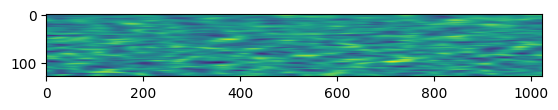

In [52]:
plt.imshow(cosmo[0, ...].real)

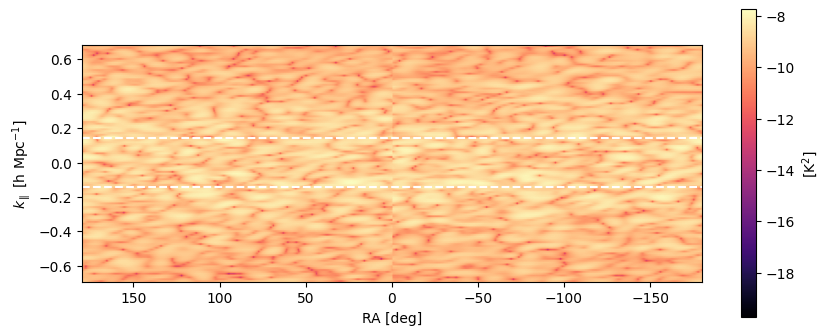

In [53]:
_ = plot_delay_spectrum(cosmo, bl_ind=ibase)

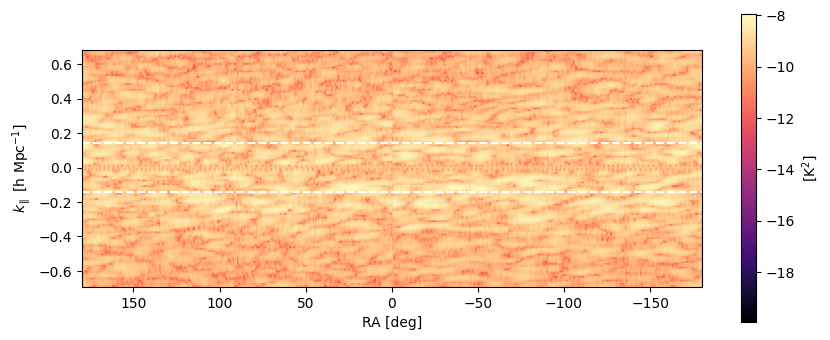

In [54]:
_ = plot_delay_spectrum(net_pred, bl_ind=ibase)

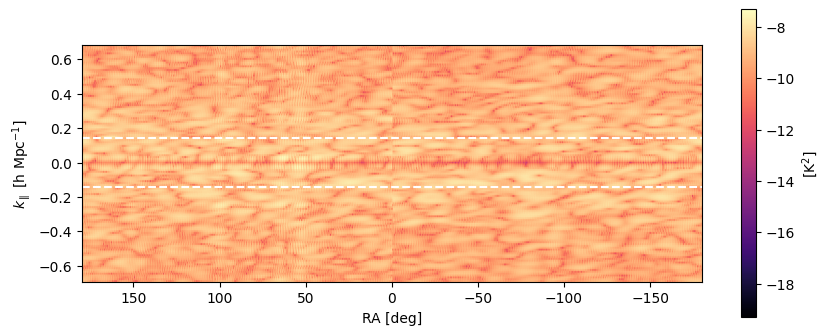

In [55]:
_ = plot_delay_spectrum(pca_pred, bl_ind=ibase)

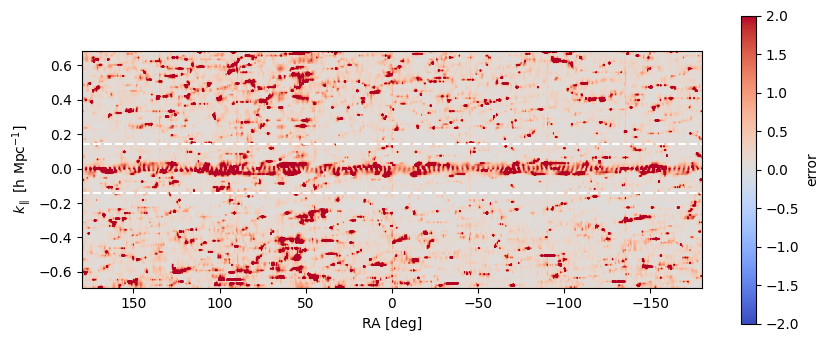

In [56]:
(fig,res_delay_spec_unet) = plot_delay_spectrum_of_residual(net_pred, cosmo, bl_ind=ibase, rel_range=3)

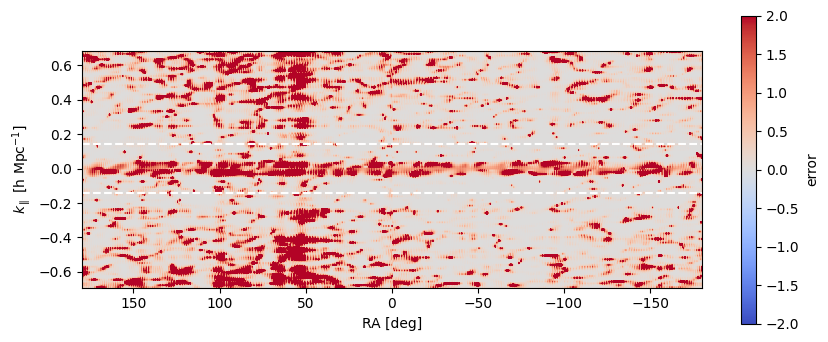

In [57]:
(_, res_delay_spec_pca7) = plot_delay_spectrum_of_residual(pca_pred, cosmo, bl_ind=ibase, rel_range=3)

In [58]:
def delay_spectrum_res_1D(data1, data_true, bl_ind, band_center=550*units.MHz, wedge_angle=90*units.deg, rel_range=12):
    
    delays1, k_par, delay_spec1 = baseline_delay_spectrum(data1, bl_ind, band_center=band_center)
    
    delays2, k_par, delay_spec2 = baseline_delay_spectrum(data_true, bl_ind, band_center=band_center)
    
    delay_spec = (delay_spec1 - delay_spec2) / delay_spec2
    
    ras = np.linspace(180, -180, delay_spec.shape[1] + 1)
    
    return np.mean(delay_spec, -1), k_par

In [59]:
pca7_res_spec,kpar = delay_spectrum_res_1D(pca_pred, cosmo, bl_ind=7)
unet_res_spec,kpar = delay_spectrum_res_1D(net_pred, cosmo, bl_ind=7)

Text(0, 0.5, '$\\frac{P_{\\rm pred} - P_{\\rm cosmo}}{P_{\\rm cosmo}}$')

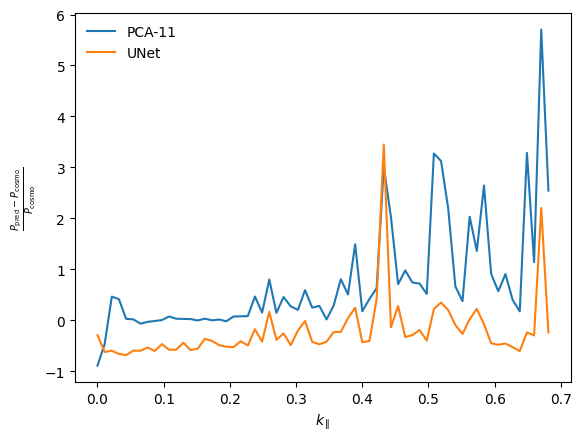

In [60]:
nyquist = 128 // 2

plt.plot(kpar[nyquist:], pca7_res_spec[nyquist:], label="PCA-%d"%(N_FG))
plt.plot(kpar[nyquist:], unet_res_spec[nyquist:], label="UNet")
#plt.yscale('log')
plt.legend(framealpha=0.0)
plt.xlabel(r"$k_\parallel$")
plt.ylabel(r"$\frac{P_{\rm pred} - P_{\rm cosmo}}{P_{\rm cosmo}}$")

In [61]:
cosmo_test_files[6]

'/data101/makinen/hirax_sims/cosmo_test_set/cosmo_H0_72p7345_vis_90.h5'

In [62]:
def residual_delay_spec_1D(data1, data_true, bl_ind, band_center=550*units.MHz, wedge_angle=90*units.deg, rel_range=12):
    
    delays, k_par, delay_spec = baseline_delay_spectrum((data1 - data_true), bl_ind, band_center=band_center)
    
    delays, k_par, delay_spec2 = baseline_delay_spectrum((data_true), bl_ind, band_center=band_center)

    delay_spec /= delay_spec2
    
    ras = np.linspace(180, -180, delay_spec.shape[1] + 1)
    
    return np.mean(delay_spec, -1), k_par

In [63]:
pca7_spec_res,kpar = residual_delay_spec_1D(pca_pred, cosmo, bl_ind=7)
unet_spec_res,kpar = residual_delay_spec_1D(net_pred, cosmo, bl_ind=7)

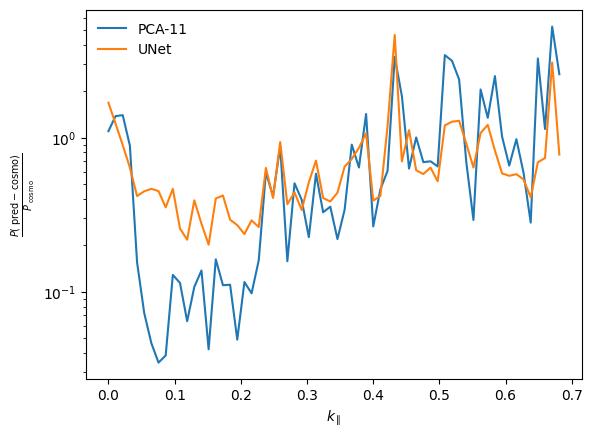

In [64]:
nyquist = 128 // 2

plt.plot(kpar[nyquist:], pca7_spec_res[nyquist:], label='PCA-%d'%(N_FG))
plt.plot(kpar[nyquist:], unet_spec_res[nyquist:], label='UNet')
plt.ylabel(r"$\frac{P({\ \rm pred} - {\rm cosmo})}{P_{\ \rm cosmo}}$")
plt.xlabel(r"$k_\parallel$")
plt.legend(framealpha=0.0)
plt.yscale('log')

In [65]:
history = load_obj("/data101/makinen/hirax_sims/accelerator/default_17_10train_history_inprog.pkl")

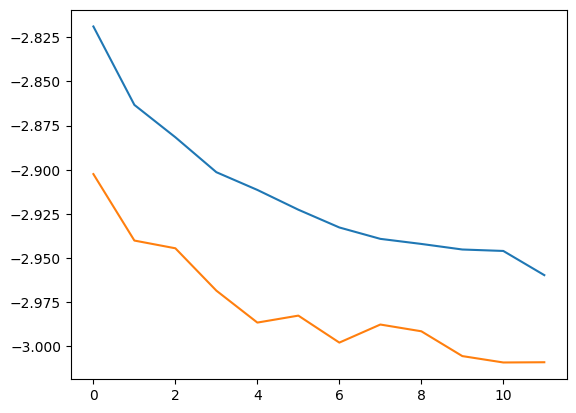

In [68]:
plt.plot(history['train_loss'][2:])
plt.plot(history['val_loss'][2:])

In [37]:
EPOCHS

10